Lade ENA-Metadaten...
ENA-Daten: 678 Samples

Copenhagen: 12 Samples, 230 Viren
  Korrelation Temp–Shannon: r=-0.238, p=0.4564 nicht signifikant

Guangzhou: 14 Samples, 177 Viren
  Korrelation Temp–Shannon: r=-0.677, p=0.0079 SIGNIFIKANT (p<0.05)

Kuala Lumpur: 15 Samples, 154 Viren
  Korrelation Temp–Shannon: r=-0.256, p=0.3566 nicht signifikant

Melbourne: 15 Samples, 427 Viren
  Korrelation Temp–Shannon: r=0.594, p=0.0196 SIGNIFIKANT (p<0.05)

Quito: 15 Samples, 148 Viren
  Korrelation Temp–Shannon: r=-0.390, p=0.1505 nicht signifikant

Regina: 15 Samples, 253 Viren
  Korrelation Temp–Shannon: r=0.561, p=0.0295 SIGNIFIKANT (p<0.05)

Seattle: 15 Samples, 242 Viren
  Korrelation Temp–Shannon: r=0.358, p=0.1896 nicht signifikant

Yaounde: 16 Samples, 330 Viren
  Korrelation Temp–Shannon: r=-0.200, p=0.4582 nicht signifikant



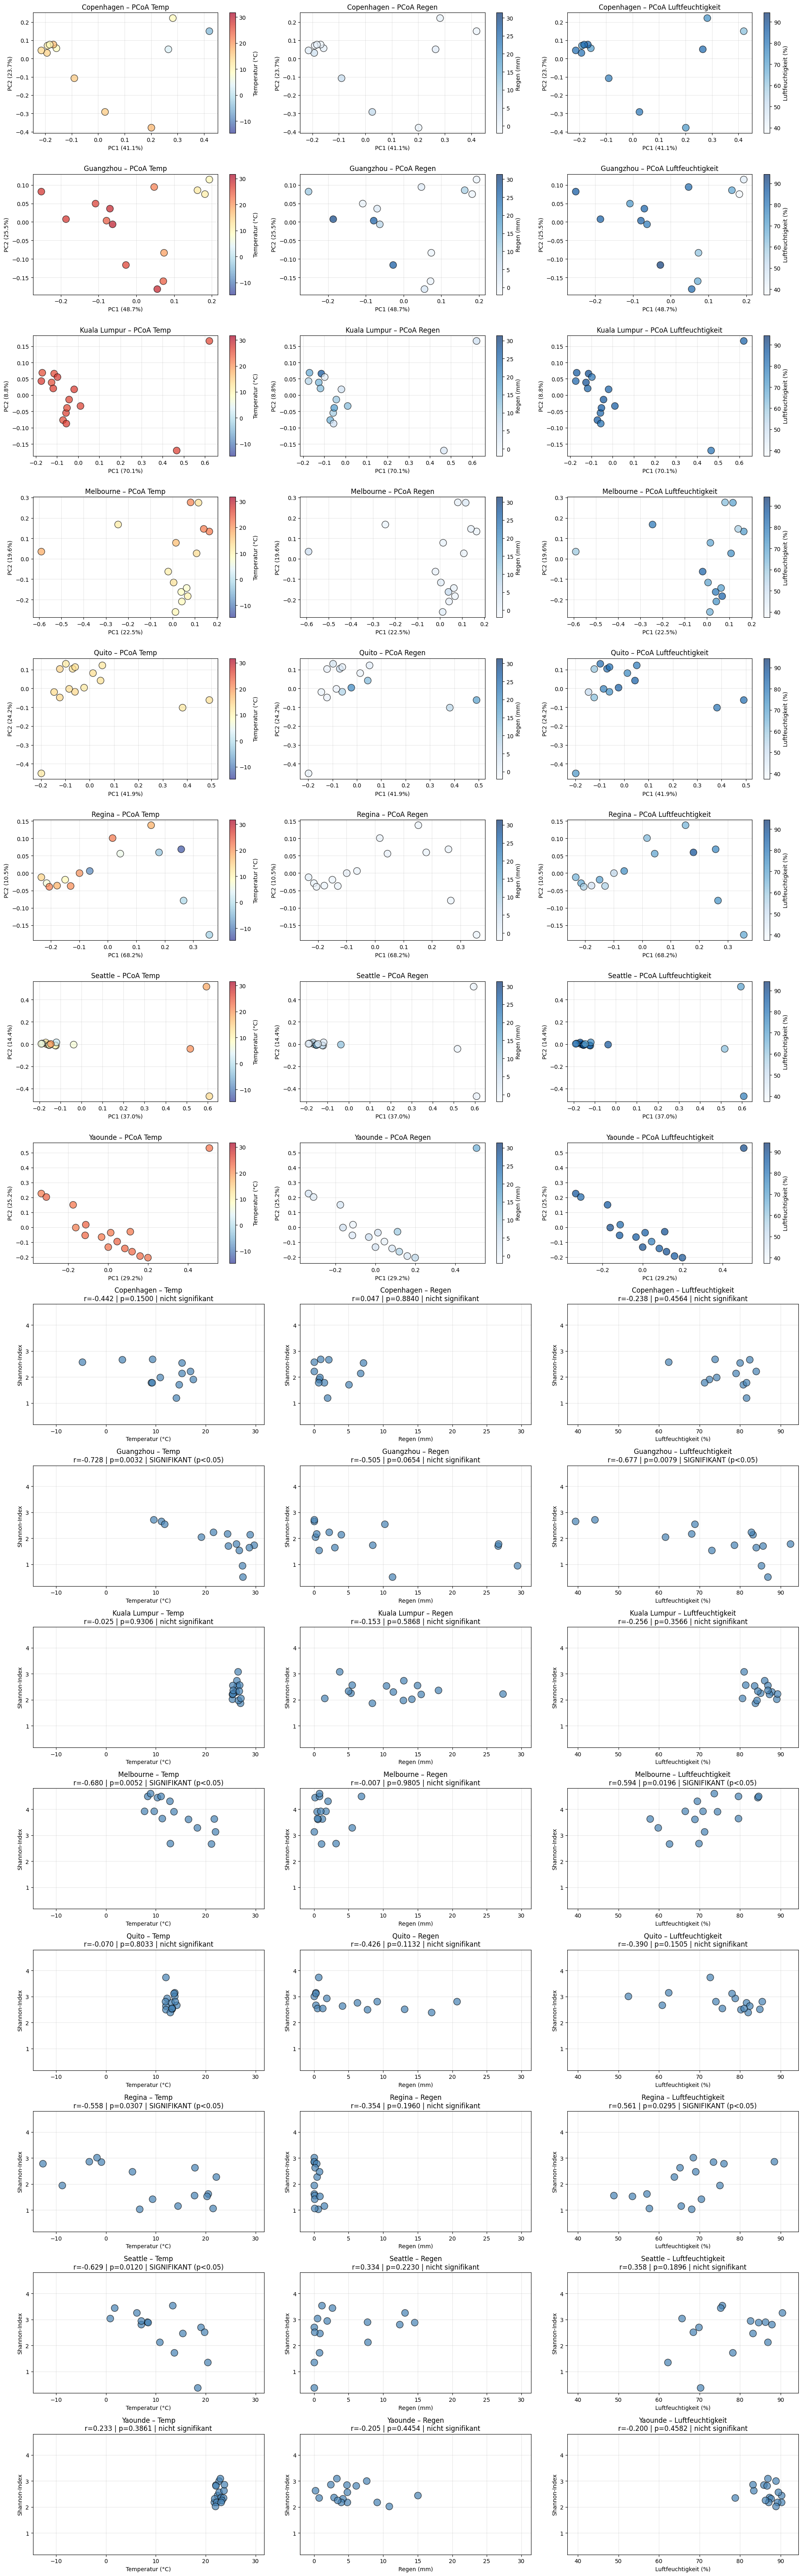

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from skbio.diversity.alpha import shannon
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa
from scipy.stats import pearsonr

warnings.filterwarnings('ignore')

# Dateipfade pro Stadt
cities = {
    'Copenhagen':   ('Copenhagen_merged_reads.csv',  'Copenhagen_weather.csv'),
    'Guangzhou':    ('Guangzhou_merged_reads.csv',   'Guangzhou_weather.csv'),
    'Kuala Lumpur': ('KualaLumpur_merged_reads.csv', 'KualaLumpur_weather.csv'),
    'Melbourne':    ('Melbourne_merged_reads.csv',   'Melbourne_weather.csv'),
    'Quito':        ('Quito_merged_reads.csv',       'Quito_weather.csv'),
    'Regina':       ('Regina_merged_reads.csv',      'Regina_weather.csv'),
    'Seattle':      ('Seattle_merged_reads.csv',     'Seattle_weather.csv'),
    'Yaounde':      ('Yaounde_merged_reads.csv',     'Yaounde_weather.csv'),
}


wetter_spalten = {
    'temperature_2m_mean (°C)':      'Temp',
    'rain_sum (mm)':                 'Regen',
    'relative_humidity_2m_mean (%)': 'Luftfeuchtigkeit',
}

print("Lade ENA-Metadaten...")
ena_data = pd.read_csv('ena_data.tsv', sep='\t')
print(f"ENA-Daten: {len(ena_data)} Samples\n")


# Daten laden, berechnen, speichern 

alle_daten = {}
alle_virus  = {}
alle_pcoa   = {}

for city, (virus_file, weather_file) in cities.items():

    # Virus-Tabelle laden (Zeilen = Samples, Spalten = Virusarten)
    virus_df = pd.read_csv(virus_file, index_col=0).fillna(0).T
    virus_df.columns = virus_df.columns.str.strip()
    virus_df = virus_df.drop('taxid', errors='ignore')

    # Shannon-Diversität pro Sample
    alpha_div = pd.DataFrame([
        {'Sample': sid, 'Shannon': shannon(virus_df.loc[sid].values)}
        for sid in virus_df.index
    ])

    # Datum ENA-Metadaten holen
    ena_city = (
        ena_data[ena_data['run_accession'].isin(alpha_div['Sample'])]
        [['run_accession', 'collection_date']]
        .copy()
        .rename(columns={'run_accession': 'Sample', 'collection_date': 'Date'})
    )
    ena_city['Date'] = pd.to_datetime(ena_city['Date'])

    data = alpha_div.merge(ena_city, on='Sample')

    # Wetterdaten laden
    weather_df = pd.read_csv(weather_file)
    weather_df['time'] = pd.to_datetime(weather_df['time'])

    # Mittelwert plus 4 Tage vor Sammeldatum
    for csv_spalte, col_name in wetter_spalten.items():
        data[col_name] = np.nan
        for i, row in data.iterrows():
            start = row['Date'] - pd.Timedelta(days=4)
            maske = (weather_df['time'] >= start) & (weather_df['time'] <= row['Date'])
            data.at[i, col_name] = weather_df.loc[maske, csv_spalte].mean()

    data_clean = data.dropna(subset=list(wetter_spalten.values()) + ['Shannon'])

    # Beta-Diversität (Bray-Curtis) und PCoA berechnen
    bc_dm    = beta_diversity('braycurtis', virus_df.values, virus_df.index)
    pcoa_res = pcoa(bc_dm)

    alle_daten[city] = data_clean
    alle_virus[city] = virus_df
    alle_pcoa[city]  = pcoa_res



gesamt_df = pd.concat(alle_daten.values(), ignore_index=True)
grenzen = {
    'Temp':             (gesamt_df['Temp'].min() - 2,             gesamt_df['Temp'].max() + 2),
    'Regen':            (gesamt_df['Regen'].min() - 2,            gesamt_df['Regen'].max() + 2),
    'Luftfeuchtigkeit': (gesamt_df['Luftfeuchtigkeit'].min() - 2, gesamt_df['Luftfeuchtigkeit'].max() + 2),
    'Shannon':          (gesamt_df['Shannon'].min() - 0.2,        gesamt_df['Shannon'].max() + 0.2),
}


# Plots


plot_config = [
    ('Temp',             'RdYlBu_r', 'Temperatur (°C)'),
    ('Regen',            'Blues',    'Regen (mm)'),
    ('Luftfeuchtigkeit', 'Blues',    'Luftfeuchtigkeit (%)'),
]

n_cities = len(cities)
fig, axes = plt.subplots(n_cities * 2, 3, figsize=(20, 8 * n_cities))

for idx, city in enumerate(cities.keys()):
    try:
        data_clean = alle_daten[city]
        virus_df   = alle_virus[city]
        pcoa_res   = alle_pcoa[city]

        print(f"{city}: {len(virus_df)} Samples, {len(virus_df.columns)} Viren")

        pc1 = pcoa_res.samples['PC1']
        pc2 = pcoa_res.samples['PC2']

        # Wetterwerte Reihenfolge PCoA-Samples zuordnen
        wetter = (
            virus_df.index.to_frame(name='Sample')
            .merge(data_clean[['Sample'] + list(wetter_spalten.values())], on='Sample', how='left')
        )

        # PCoA-Plot, eingefärbt nach Wetter-Variable
        for col_idx, (col, cmap, label) in enumerate(plot_config):
            vmin, vmax = grenzen[col]
            sc = axes[idx, col_idx].scatter(
                pc1, pc2, s=150, c=wetter[col], cmap=cmap,
                vmin=vmin, vmax=vmax, alpha=0.7, edgecolors='black', linewidth=1
            )
            axes[idx, col_idx].set_xlabel(f'PC1 ({pcoa_res.proportion_explained[0]:.1%})')
            axes[idx, col_idx].set_ylabel(f'PC2 ({pcoa_res.proportion_explained[1]:.1%})')
            axes[idx, col_idx].set_title(f'{city} – PCoA {col}')
            axes[idx, col_idx].grid(True, alpha=0.3)
            plt.colorbar(sc, ax=axes[idx, col_idx], label=label)

        # Korrelation Wetter-Variable vs. Shannon-Diversität
        if len(data_clean) > 2:
            for col_idx, (col, _, label) in enumerate(plot_config):
                r, p = pearsonr(data_clean[col], data_clean['Shannon'])
                sig_text = 'SIGNIFIKANT (p<0.05)' if p < 0.05 else 'nicht signifikant'
                vmin, vmax = grenzen[col]
                ax = axes[idx + n_cities, col_idx]
                ax.scatter(data_clean[col], data_clean['Shannon'],
                           s=150, alpha=0.7, edgecolors='black', linewidth=1, color='steelblue')
                ax.set_xlabel(label)
                ax.set_ylabel('Shannon-Index')
                ax.set_xlim(vmin, vmax)
                ax.set_ylim(*grenzen['Shannon'])
                ax.set_title(f'{city} – {col}\nr={r:.3f} | p={p:.4f} | {sig_text}')
                ax.grid(True, alpha=0.3)

            print(f"  Korrelation Temp–Shannon: r={r:.3f}, p={p:.4f} {sig_text}\n")

    except Exception as e:
        print(f"Fehler bei {city}: {e}\n")

plt.tight_layout()
plt.show()


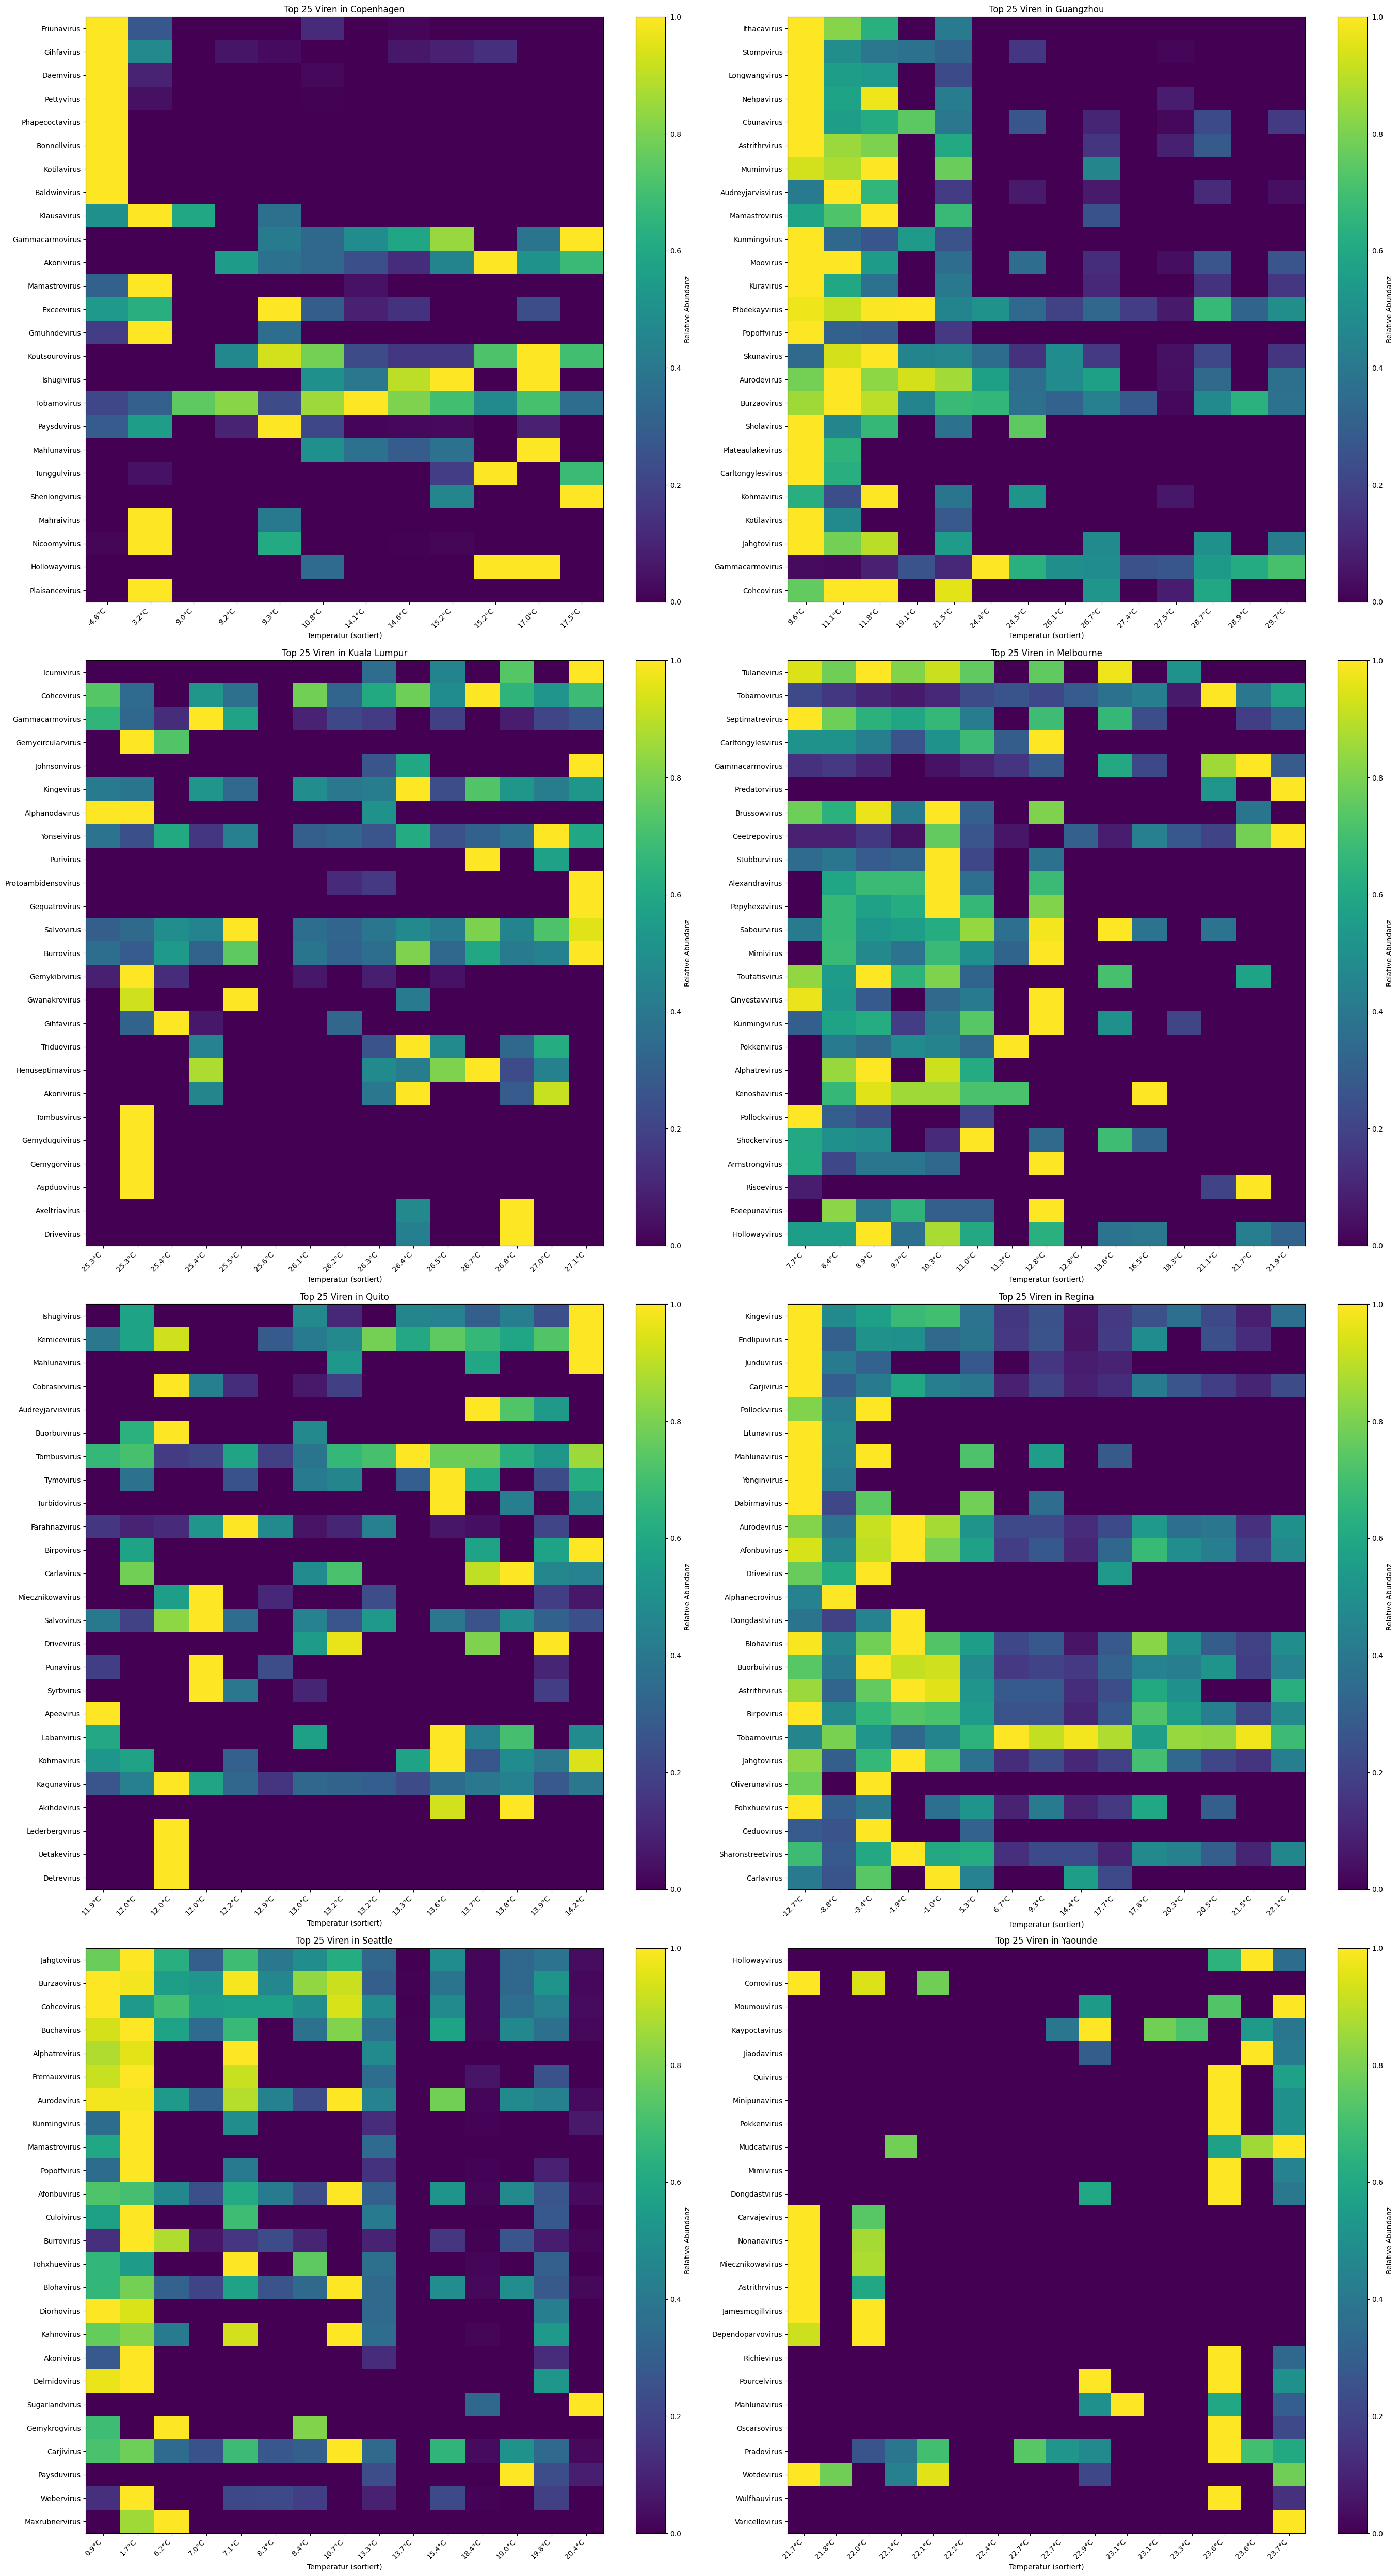

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(28, 50))

for idx, city in enumerate(cities.keys()):
    ax = axes[idx // 2, idx % 2]

    virus_city = alle_virus[city]
    daten_city = alle_daten[city]

    # Proben nach Temperatur sortieren
    daten_sorted = daten_city.sort_values('Temp')
    virus_sorted = virus_city.loc[daten_sorted['Sample'].values]

    # Pearson-Korrelation Virus mit Temperatur -> Top 25 
    korrelationen = {
        v: abs(pearsonr(daten_sorted['Temp'], virus_sorted[v])[0])
        for v in virus_sorted.columns
    }
    top25 = sorted(korrelationen, key=korrelationen.get, reverse=True)[:25]

   # Temp zeilen index 
    virus_top25 = virus_sorted[top25].copy()
    virus_top25.index = (daten_sorted['Temp'].round(1).astype(str) + '°C').values

    # relatives Maximum normalisieren (0–1 pro Virus)
    virus_norm = virus_top25.T
    virus_norm = virus_norm.div(virus_norm.max(axis=1), axis=0).fillna(0)

    im = ax.imshow(virus_norm.values, cmap='viridis', aspect='auto')
    plt.colorbar(im, ax=ax, label='Relative Abundanz')
    ax.set_xticks(range(len(virus_norm.columns)))
    ax.set_xticklabels(virus_norm.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(virus_norm.index)))
    ax.set_yticklabels(virus_norm.index)
    ax.set_title(f'Top 25 Viren in {city}')
    ax.set_xlabel('Temperatur (sortiert)')

plt.tight_layout()
plt.show()


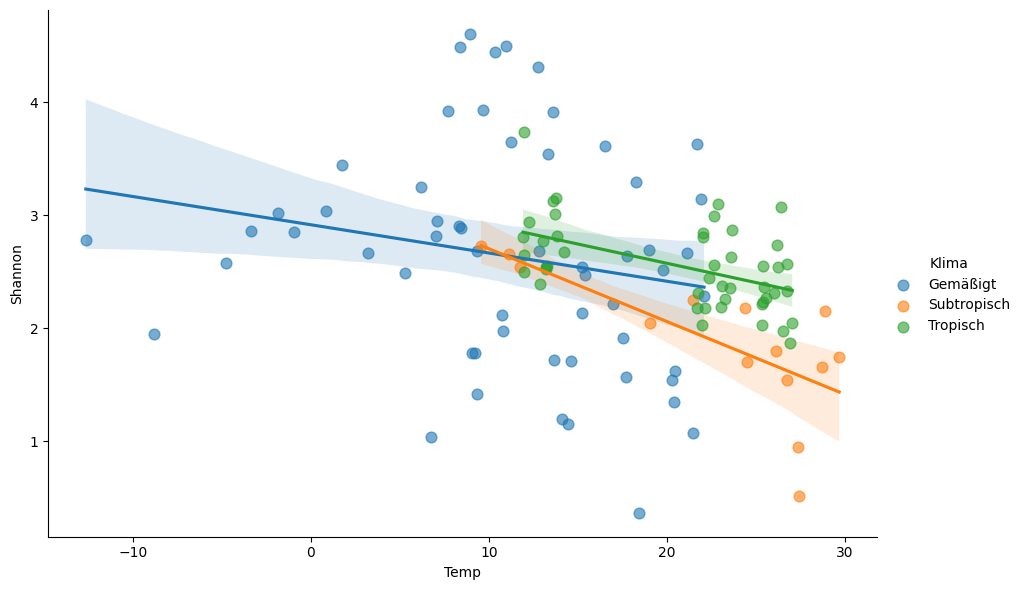

In [7]:
klimagruppen = {
    'Copenhagen':   'Gemäßigt',
    'Melbourne':    'Gemäßigt',
    'Regina':       'Gemäßigt',
    'Seattle':      'Gemäßigt',
    'Guangzhou':    'Subtropisch',
    'Kuala Lumpur': 'Tropisch',
    'Quito':        'Tropisch',
    'Yaounde':      'Tropisch',
}

alle_zusammen = []
for city, data_clean in alle_daten.items():
    df = data_clean[['Temp', 'Shannon']].copy()
    df['Stadt'] = city
    df['Klima'] = klimagruppen[city]
    alle_zusammen.append(df)

gesamt = pd.concat(alle_zusammen, ignore_index=True)

# Alle Klimazonen in einem Plot
sns.lmplot(
    data=gesamt, x='Temp', y='Shannon',
    hue='Klima',
    height=6, aspect=1.5,
    scatter_kws={'alpha': 0.6, 's': 60},
)